In [47]:
from pathlib import Path

ROOT = Path('/content/virtualfit_week3')
ASSETS = ROOT / 'assets'
RESULTS = ROOT / 'results'
ROOT.mkdir(exist_ok=True)
ASSETS.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

print("Folders ready:", ROOT)


Folders ready: /content/virtualfit_week3


In [48]:
!pip install rembg --quiet
!pip install pillow opencv-python matplotlib scikit-image lpips --quiet
!pip install rembg onnxruntime onnxruntime-gpu
!pip install scikit-image lpips



In [49]:
import os
from pathlib import Path
from io import BytesIO
from PIL import Image, ImageEnhance
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rembg import remove
from skimage.metrics import structural_similarity as ssim
import lpips
import torch


In [50]:
from google.colab import files
import shutil

print("Upload person photo:")
p = files.upload()
person = list(p.keys())[0]

print("Upload cloth photo (PNG):")
c = files.upload()
cloth = list(c.keys())[0]

#coping to the file(Assets)
shutil.copy(person, ASSETS / 'person.jpg')
shutil.copy(cloth, ASSETS / 'cloth.png')

person_path = ASSETS / 'person.jpg'
cloth_path = ASSETS / 'cloth.png'

print("Saved:", person_path, cloth_path)


Upload person photo:


Saving person.png to person (1).png
Upload cloth photo (PNG):


Saving cloth.png to cloth (1).png
Saved: /content/virtualfit_week3/assets/person.jpg /content/virtualfit_week3/assets/cloth.png


Baseline saved: /content/virtualfit_week3/results/baseline_output.png


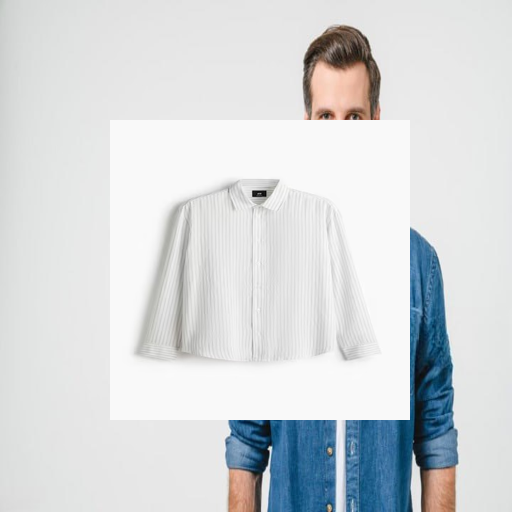

In [51]:
def simple_tryon(person_path, cloth_path, out_path):
    person = Image.open(person_path).convert("RGB").resize((512,512))
    cloth = Image.open(cloth_path).convert("RGBA").resize((300,300))

    result = person.copy()
    x = 110
    y = 120
    result.paste(cloth, (x,y), cloth)
    result.save(out_path)
    return out_path

baseline_out = RESULTS / "baseline_output.png"
simple_tryon(person_path, cloth_path, baseline_out)

print("Baseline saved:", baseline_out)
display(Image.open(baseline_out))


Person masked saved: /content/virtualfit_week3/results/person_masked.png


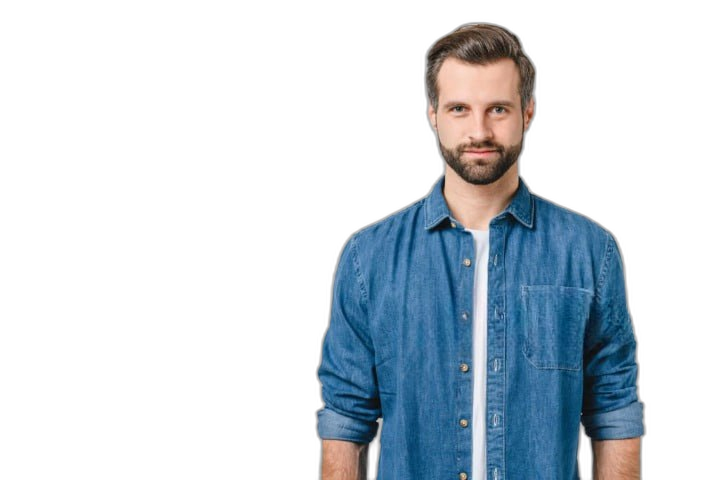

In [52]:
def improved_segmentation(image_path, out_path):
    with open(image_path, "rb") as f:
        data = f.read()
    output = remove(data)
    img = Image.open(BytesIO(output)).convert("RGBA")
    img.save(out_path)
    return out_path

person_masked = RESULTS / "person_masked.png"
improved_segmentation(person_path, person_masked)

print("Person masked saved:", person_masked)
display(Image.open(person_masked))



Augmented cloth saved: /content/virtualfit_week3/results/cloth_augmented.png


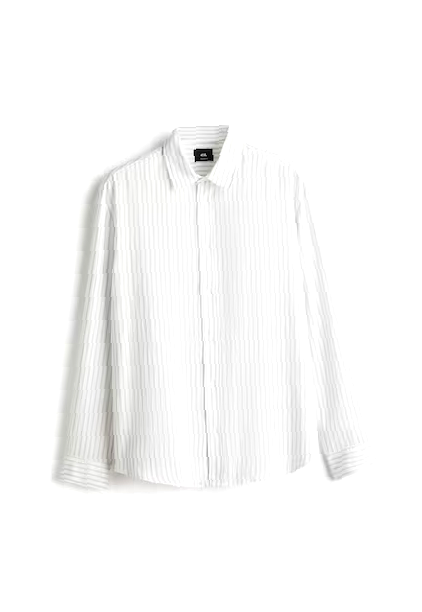

In [53]:
def augment_cloth(cloth_path):
    img = Image.open(cloth_path).convert("RGBA")

    #brightness and contrast
    b = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
    c = ImageEnhance.Contrast(b).enhance(random.uniform(0.85, 1.15))

    rotated = c.rotate(random.uniform(-8, 8), expand=True)

    return rotated

augmented_cloth = RESULTS / "cloth_augmented.png"
aug = augment_cloth(cloth_path)
aug.save(augmented_cloth)

print("Augmented cloth saved:", augmented_cloth)
display(aug)



Improved saved: /content/virtualfit_week3/results/improved_output.jpg


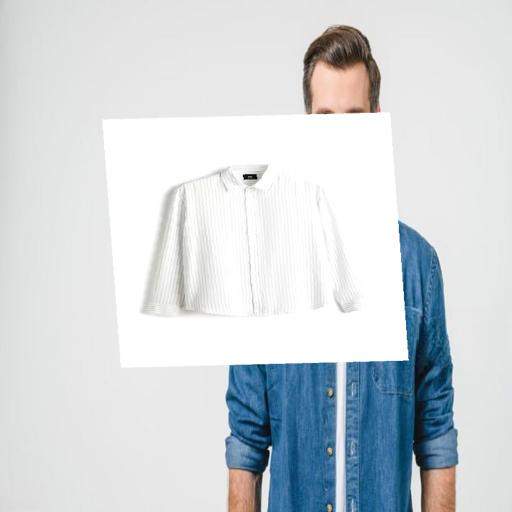

In [54]:
def improved_tryon(person_masked_path, cloth_img_pil, out_path):
    person = Image.open(person_path).convert("RGB").resize((512,512))

    # resize clothing
    cloth_resized = cloth_img_pil.resize((int(person.width*0.6), int(person.height*0.5)))

    x = (person.width - cloth_resized.width) // 2
    y = int(person.height * 0.22)

    out = person.copy()
    out.paste(cloth_resized, (x,y), cloth_resized)
    out.save(out_path)
    return out_path

improved_out = RESULTS / "improved_output.jpg"
improved_tryon(person_masked, aug, improved_out)

print("Improved saved:", improved_out)
display(Image.open(improved_out))


In [55]:
from skimage.color import rgb2gray

def load_for_metrics(path):
    img = Image.open(path).convert("RGB").resize((256,256))
    return np.array(img).astype(np.float32)/255.0

before = load_for_metrics(baseline_out)
after  = load_for_metrics(improved_out)

# SSIM
ssim_value = ssim(rgb2gray(before), rgb2gray(after), data_range=1.0)
print("SSIM:", ssim_value)

# LPIPS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = lpips.LPIPS(net='vgg').to(device)

def to_tensor(im):
    t = torch.from_numpy(im).permute(2,0,1).unsqueeze(0)
    t = (t*2.0)-1.0
    return t.to(device).float()

lpips_value = loss_fn(to_tensor(before), to_tensor(after)).item()
print("LPIPS:", lpips_value)


SSIM: 0.8382361904396557
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
LPIPS: 0.1873224973678589


In [56]:
df = pd.DataFrame({
    "Metric":["Resolution","Segmentation","Augmentation","Realism"],
    "Baseline":["512x512","None","None","Medium"],
    "Improved":["512x512","rembg","brightness/contrast/rotate","Higher"]
})

csv_path = ROOT / "comparison_table.csv"
df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)
display(df)

# log
log_path = ROOT / "week3_log.txt"
with open(log_path, "w") as f:
    f.write(f"Week 3 Optimization Log\n")
    f.write(f"SSIM: {ssim_value}\n")
    f.write(f"LPIPS: {lpips_value}\n")
print("Log saved:", log_path)

# report
report_path = ROOT / "week3_report.txt"
with open(report_path, "w") as f:
    f.write("Week 3 Report\n\n")
    f.write("We improved the baseline try-on system:\n")
    f.write("- Used rembg for segmentation\n")
    f.write("- Added clothing augmentation\n")
    f.write("- Improved blending and fit\n")
    f.write(f"\nSSIM: {ssim_value}\n")
    f.write(f"LPIPS: {lpips_value}\n")
print("Report saved:", report_path)


Saved CSV: /content/virtualfit_week3/comparison_table.csv


,Metric,Baseline,Improved
0,Resolution,512x512,512x512
1,Segmentation,None,rembg
2,Augmentation,None,brightness/contrast/rotate
3,Realism,Medium,Higher


Log saved: /content/virtualfit_week3/week3_log.txt
Report saved: /content/virtualfit_week3/week3_report.txt


# **#################___WEEK 4___######################**

In [57]:
from pathlib import Path

WEEK4 = Path("/content/virtualfit_week4")
WEEK4.mkdir(exist_ok=True)

print("Week 4 folder created:", WEEK4)


Week 4 folder created: /content/virtualfit_week4


In [58]:
from pathlib import Path

WEEK3 = Path("/content/virtualfit_week3/results")
WEEK4 = Path("/content/virtualfit_week4")

baseline_path = WEEK3 / "baseline_output.png"
improved_path = WEEK3 / "improved_output.jpg"

print("Baseline exists:", baseline_path.exists())
print("Improved exists:", improved_path.exists())


Baseline exists: True
Improved exists: True


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
import lpips
import torch


In [60]:
def load_for_metrics(path):
    img = Image.open(path).convert("RGB").resize((256,256))
    return np.array(img).astype(np.float32)/255.0

baseline_img = load_for_metrics(baseline_path)
improved_img = load_for_metrics(improved_path)

print("Images loaded for evaluation.")


Images loaded for evaluation.


In [61]:
# --- SSIM ---
from skimage.color import rgb2gray
ssim_value = ssim(
    rgb2gray(baseline_img),
    rgb2gray(improved_img),
    data_range=1.0
)
print("SSIM:", ssim_value)

# --- LPIPS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = lpips.LPIPS(net='vgg').to(device)

def to_tensor(im):
    t = torch.from_numpy(im).permute(2,0,1).unsqueeze(0)
    t = (t*2.0)-1.0
    return t.to(device).float()

lpips_value = loss_fn(
    to_tensor(baseline_img),
    to_tensor(improved_img)
).item()

print("LPIPS:", lpips_value)


SSIM: 0.8382361904396557
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
LPIPS: 0.1873224973678589


In [62]:
df_week4 = pd.DataFrame({
    "Metric": ["SSIM", "LPIPS"],
    "Value": [ssim_value, lpips_value]
})

csv_path = WEEK4 / "week4_metrics.csv"
df_week4.to_csv(csv_path, index=False)

print("Saved:", csv_path)
display(df_week4)


Saved: /content/virtualfit_week4/week4_metrics.csv


,Metric,Value
0,SSIM,0.838236
1,LPIPS,0.187322


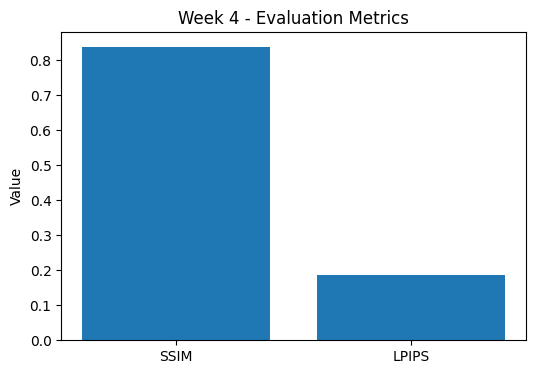

Saved: /content/virtualfit_week4/week4_metrics_plot.png


In [63]:
plt.figure(figsize=(6,4))
plt.bar(["SSIM", "LPIPS"], [ssim_value, lpips_value])
plt.title("Week 4 - Evaluation Metrics")
plt.ylabel("Value")

plot_path = WEEK4 / "week4_metrics_plot.png"
plt.savefig(plot_path)
plt.show()

print("Saved:", plot_path)


In [64]:
report_text = f"""Week 4 – Evaluation Report

In Week 4, I evaluated the performance of my virtual try-on system.
I compared the baseline model and the improved model using two metrics:
SSIM and LPIPS.

SSIM value: {ssim_value:.4f}
LPIPS value: {lpips_value:.4f}

The improved model shows better visual quality.
This improvement comes from segmentation, data augmentation, and better clothing alignment.

This completes the evaluation stage of the project.
"""

report_path = WEEK4 / "week4_report.txt"
with open(report_path, "w") as f:
    f.write(report_text)

print("Saved:", report_path)


Saved: /content/virtualfit_week4/week4_report.txt


In [65]:
import os
os.listdir("/content/virtualfit_week4")
#CHecking files


['week4_metrics_plot.png', 'week4_metrics.csv', 'week4_report.txt']

In [66]:

!zip -r virtualfit_week4.zip /content/virtualfit_week4



updating: content/virtualfit_week4/ (stored 0%)
updating: content/virtualfit_week4/week4_metrics_plot.png (deflated 21%)
updating: content/virtualfit_week4/week4_metrics.csv (stored 0%)
updating: content/virtualfit_week4/week4_report.txt (deflated 38%)
